In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import pandas as pd

# Specify the path to your dataset in Google Drive
# Example for a CSV file:
# dataset_path = '/content/drive/MyDrive/YourFolder/your_dataset.csv'
# Example for an Excel file:
# dataset_path = '/content/drive/MyDrive/YourFolder/your_dataset.xlsx'
# Example for a JSON file:
# dataset_path = '/content/drive/MyDrive/YourFolder/your_dataset.json'

dataset_path = '/content/drive/MyDrive/inetrn/healthcare_patient_dataset_clean_2000_records.csv' # <<< CHANGE THIS TO YOUR ACTUAL FILE PATH

# Load the dataset based on its type
# For CSV:
try:
    df = pd.read_csv(dataset_path)
    print(f"Dataset loaded successfully from {dataset_path}")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {dataset_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

# If it's an Excel file, you would use:
# df = pd.read_excel(dataset_path)
# If it's a JSON file, you would use:
# df = pd.read_json(dataset_path)
# etc.

# Now 'df' contains your dataset

Dataset loaded successfully from /content/drive/MyDrive/inetrn/healthcare_patient_dataset_clean_2000_records.csv
  Patient_ID   Age  Gender Blood_Type       City        Department  \
0    P100001  52.0  Female        AB+   Peshawar        Cardiology   
1    P100002  15.0    Male         O+     Lahore        Pediatrics   
2    P100003  72.0    Male         A-  Islamabad       Orthopedics   
3    P100004  61.0    Male         B+   Peshawar  General Medicine   
4    P100005  21.0    Male         B-     Lahore        Cardiology   

  Admission_Date      Diagnosis      Treatment   Medication  Stay_Days  \
0     2025-08-26       Diabetes    Observation   Amlodipine         14   
1     2025-07-28      Arthritis  Physiotherapy  Amoxicillin          8   
2     2024-01-29  Heart Disease     Medication  Amoxicillin          5   
3     2025-12-22       Migraine        Surgery    Ibuprofen         30   
4     2025-06-07         Asthma        Therapy   Amlodipine         19   

   Medical_Cost   Ins

In [39]:
print(df.shape)

(2000, 15)


In [40]:
print(df.columns)

Index(['Patient_ID', 'Age', 'Gender', 'Blood_Type', 'City', 'Department',
       'Admission_Date', 'Diagnosis', 'Treatment', 'Medication', 'Stay_Days',
       'Medical_Cost', 'Insurance', 'Satisfaction_Score', 'Order_Status'],
      dtype='object')


In [41]:
print(df.isnull().sum())

Patient_ID              0
Age                    12
Gender                  0
Blood_Type              0
City                   10
Department              0
Admission_Date          0
Diagnosis               0
Treatment               0
Medication            294
Stay_Days               0
Medical_Cost           10
Insurance               0
Satisfaction_Score      8
Order_Status            0
dtype: int64


/tmp/ipykernel_858/867208934.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')


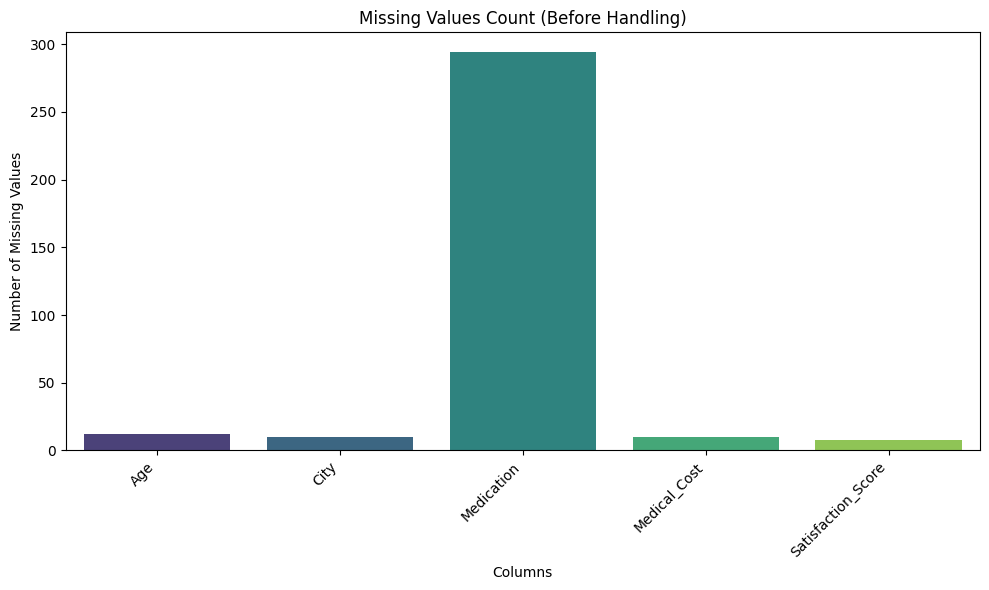

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0] # Filter columns with missing values

if not missing_values.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
    plt.title('Missing Values Count (Before Handling)')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")

In [43]:
import numpy as np

# Impute numerical columns with the median
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Medical_Cost'].fillna(df['Medical_Cost'].median(), inplace=True)
df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].median(), inplace=True)

# Impute categorical columns with the mode
df['City'].fillna(df['City'].mode()[0], inplace=True)
df['Medication'].fillna(df['Medication'].mode()[0], inplace=True)

# Verify missing values after handling
missing_values_after_handling = df.isnull().sum()
missing_values_after_handling = missing_values_after_handling[missing_values_after_handling > 0]

if not missing_values_after_handling.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_values_after_handling.index, y=missing_values_after_handling.values, palette='viridis')
    plt.title('Missing Values Count (After Handling)')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset after handling.")


No missing values found in the dataset after handling.


/tmp/ipykernel_858/3428181922.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_858/3428181922.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [44]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")

if not duplicate_rows.empty:
    print("\nFirst 5 duplicate rows (if any):")
    display(duplicate_rows.head())

Number of duplicate rows: 0


In [45]:
print("Duplicates before removal:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates after removal:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)

Duplicates before removal: 0
Duplicates after removal: 0
Dataset shape after removing duplicates: (2000, 15)


In [46]:
import numpy as np

# Select numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detect outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not outliers.empty:
        print(f"Column '{col}': {len(outliers)} outliers detected.")
        # Optional: Display some outliers
        # display(outliers[[col]].head())

        # Handle outliers by capping them to the bounds
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        print(f"Outliers in '{col}' have been capped to their respective bounds.")
    else:
        print(f"Column '{col}': No outliers detected using the IQR method.")

print("\nOutlier detection and handling complete.")

Column 'Age': No outliers detected using the IQR method.
Column 'Stay_Days': 4 outliers detected.
Outliers in 'Stay_Days' have been capped to their respective bounds.
Column 'Medical_Cost': 4 outliers detected.
Outliers in 'Medical_Cost' have been capped to their respective bounds.
Column 'Satisfaction_Score': No outliers detected using the IQR method.

Outlier detection and handling complete.


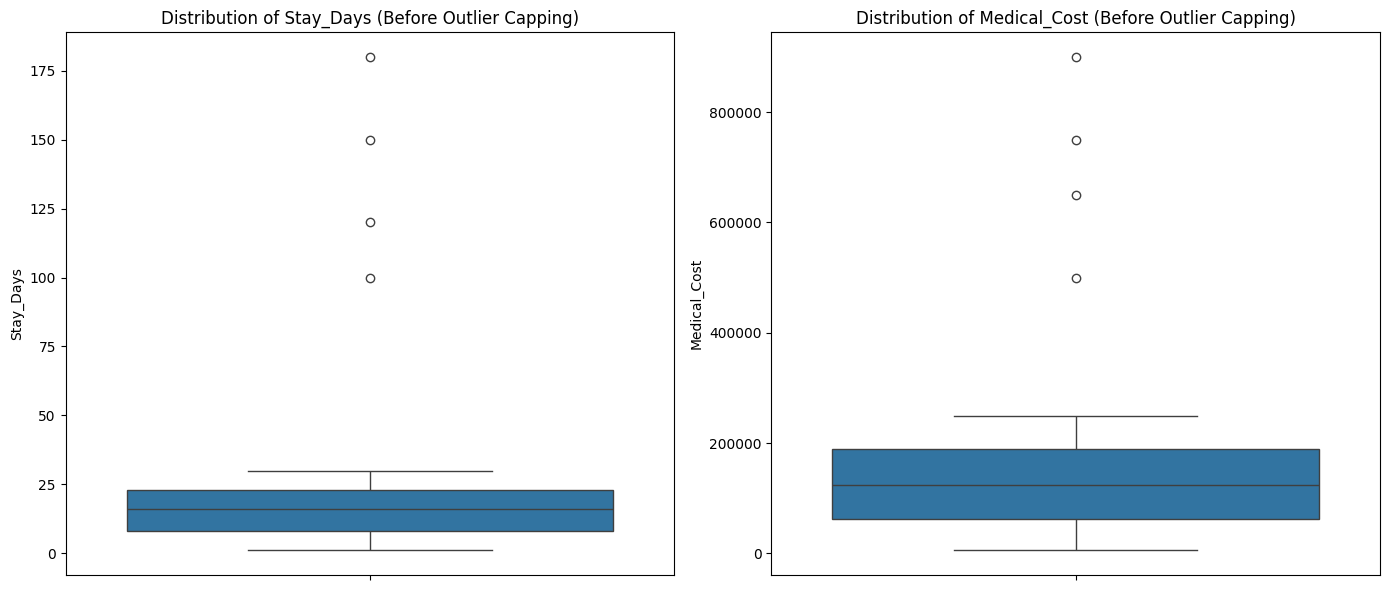

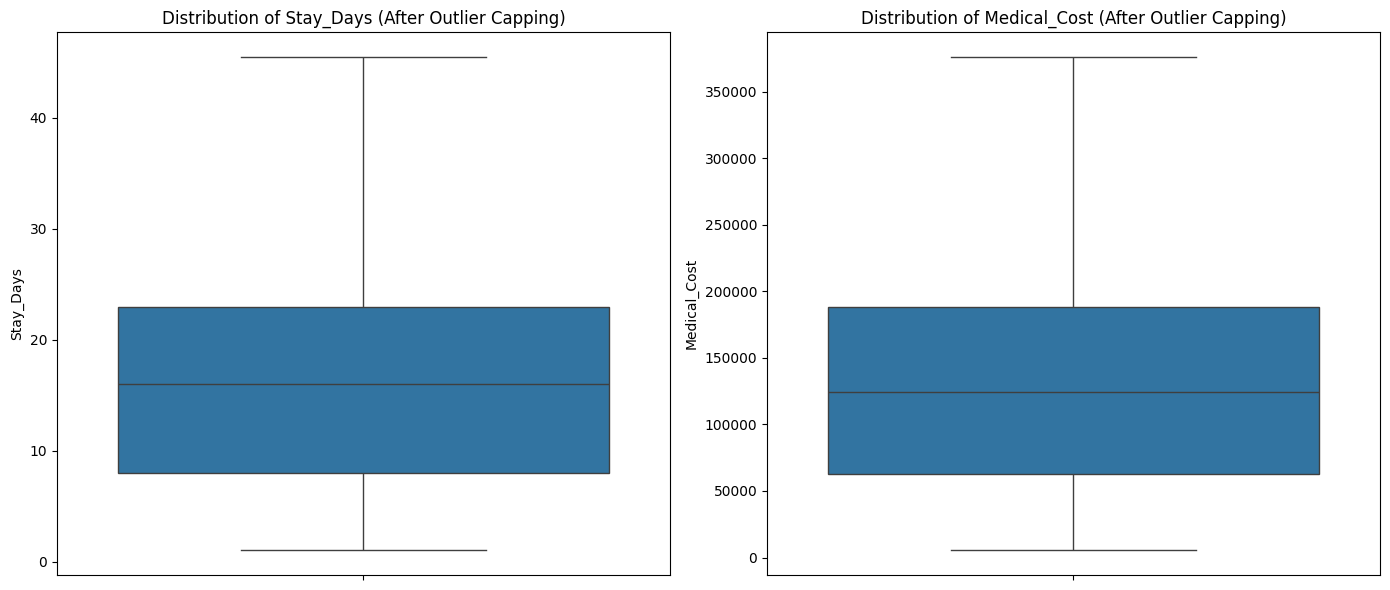

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Graph Before Outlier Handling ---
# Reload the original dataset to get the state before outlier handling
df_before = pd.read_csv(dataset_path)

# Columns that previously showed outliers, chosen for visualization
columns_to_plot = ['Stay_Days', 'Medical_Cost'] # Corrected column names

plt.figure(figsize=(14, 6))
for i, col in enumerate(columns_to_plot):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(y=df_before[col])
    plt.title(f'Distribution of {col} (Before Outlier Capping)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# --- Graph After Outlier Handling ---
# The current 'df' already contains the data after outlier handling
# Plotting the same columns from the modified df
plt.figure(figsize=(14, 6))
for i, col in enumerate(columns_to_plot):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Distribution of {col} (After Outlier Capping)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [48]:
print(df.dtypes)

Patient_ID             object
Age                   float64
Gender                 object
Blood_Type             object
City                   object
Department             object
Admission_Date         object
Diagnosis              object
Treatment              object
Medication             object
Stay_Days             float64
Medical_Cost          float64
Insurance              object
Satisfaction_Score    float64
Order_Status           object
dtype: object


In [49]:
print("Data types before coversion")
print(df.dtypes)
# Convert Date column to datetime
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'], errors='coerce')

print("\nData types after conversion:")
print(df.dtypes)

Data types before coversion
Patient_ID             object
Age                   float64
Gender                 object
Blood_Type             object
City                   object
Department             object
Admission_Date         object
Diagnosis              object
Treatment              object
Medication             object
Stay_Days             float64
Medical_Cost          float64
Insurance              object
Satisfaction_Score    float64
Order_Status           object
dtype: object

Data types after conversion:
Patient_ID                    object
Age                          float64
Gender                        object
Blood_Type                    object
City                          object
Department                    object
Admission_Date        datetime64[ns]
Diagnosis                     object
Treatment                     object
Medication                    object
Stay_Days                    float64
Medical_Cost                 float64
Insurance                     obje

In [50]:
# Encode Categorical Variables

categorical_cols = [
    'Gender',
    'Blood_Type',
    'City',
    'Department',
    'Diagnosis',
    'Treatment',
    'Medication',
    'Insurance',
    'Order_Status'
]

print("Categorical columns before encoding:")
print(categorical_cols)

# One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("\nCategorical variables encoded successfully!")
print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)

display(df_encoded.head())

Categorical columns before encoding:
['Gender', 'Blood_Type', 'City', 'Department', 'Diagnosis', 'Treatment', 'Medication', 'Insurance', 'Order_Status']

Categorical variables encoded successfully!
Shape before encoding: (2000, 15)
Shape after encoding: (2000, 46)


,Patient_ID,Age,Admission_Date,Stay_Days,Medical_Cost,Satisfaction_Score,Gender_Male,Blood_Type_A-,Blood_Type_AB+,Blood_Type_AB-,...,Medication_Amoxicillin,Medication_Aspirin,Medication_Ibuprofen,Medication_Metformin,Medication_Salbutamol,Insurance_Private,Insurance_Self-Pay,Order_Status_Follow-up Required,Order_Status_Recovered,Order_Status_Under Treatment
0,P100001,52.0,2025-08-26,14.0,189537.29,8.1,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,P100002,15.0,2025-07-28,8.0,140583.01,8.8,True,False,False,False,...,True,False,False,False,False,True,False,False,True,False
2,P100003,72.0,2024-01-29,5.0,93761.78,1.9,True,True,False,False,...,True,False,False,False,False,True,False,False,False,True
3,P100004,61.0,2025-12-22,30.0,94437.56,4.2,True,False,False,False,...,False,False,True,False,False,False,True,False,False,True
4,P100005,21.0,2025-06-07,19.0,220457.24,6.8,True,False,False,False,...,False,False,False,False,False,False,True,True,False,False


In [51]:
categorical_cols = [
    'Gender',
    'Blood_Type',
    'City',
    'Department',
    'Diagnosis',
    'Treatment',
    'Medication',
    'Insurance',
    'Order_Status'
]

print("Categorical columns to be encoded:")
print(categorical_cols)

# Apply one-hot encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("\nDataFrame shape after one-hot encoding:", df_encoded.shape)

print("\nFirst 5 rows after encoding:")
display(df_encoded.head())

Categorical columns to be encoded:
['Gender', 'Blood_Type', 'City', 'Department', 'Diagnosis', 'Treatment', 'Medication', 'Insurance', 'Order_Status']

DataFrame shape after one-hot encoding: (2000, 46)

First 5 rows after encoding:


,Patient_ID,Age,Admission_Date,Stay_Days,Medical_Cost,Satisfaction_Score,Gender_Male,Blood_Type_A-,Blood_Type_AB+,Blood_Type_AB-,...,Medication_Amoxicillin,Medication_Aspirin,Medication_Ibuprofen,Medication_Metformin,Medication_Salbutamol,Insurance_Private,Insurance_Self-Pay,Order_Status_Follow-up Required,Order_Status_Recovered,Order_Status_Under Treatment
0,P100001,52.0,2025-08-26,14.0,189537.29,8.1,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,P100002,15.0,2025-07-28,8.0,140583.01,8.8,True,False,False,False,...,True,False,False,False,False,True,False,False,True,False
2,P100003,72.0,2024-01-29,5.0,93761.78,1.9,True,True,False,False,...,True,False,False,False,False,True,False,False,False,True
3,P100004,61.0,2025-12-22,30.0,94437.56,4.2,True,False,False,False,...,False,False,True,False,False,False,True,False,False,True
4,P100005,21.0,2025-06-07,19.0,220457.24,6.8,True,False,False,False,...,False,False,False,False,False,False,True,True,False,False


In [52]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns
numerical_cols = df_encoded.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns to be standardized:")
print(numerical_cols)

# Standardize numerical features
scaler = StandardScaler()

df_encoded[numerical_cols] = scaler.fit_transform(
    df_encoded[numerical_cols]
)

print("\nNumerical features standardized successfully!")

print("\nMean after standardization:")
print(df_encoded[numerical_cols].mean().round(4))

print("\nStandard deviation after standardization:")
print(df_encoded[numerical_cols].std().round(4))

Numerical columns to be standardized:
['Age', 'Stay_Days', 'Medical_Cost', 'Satisfaction_Score']

Numerical features standardized successfully!

Mean after standardization:
Age                   0.0
Stay_Days            -0.0
Medical_Cost         -0.0
Satisfaction_Score   -0.0
dtype: float64

Standard deviation after standardization:
Age                   1.0003
Stay_Days             1.0003
Medical_Cost          1.0003
Satisfaction_Score    1.0003
dtype: float64


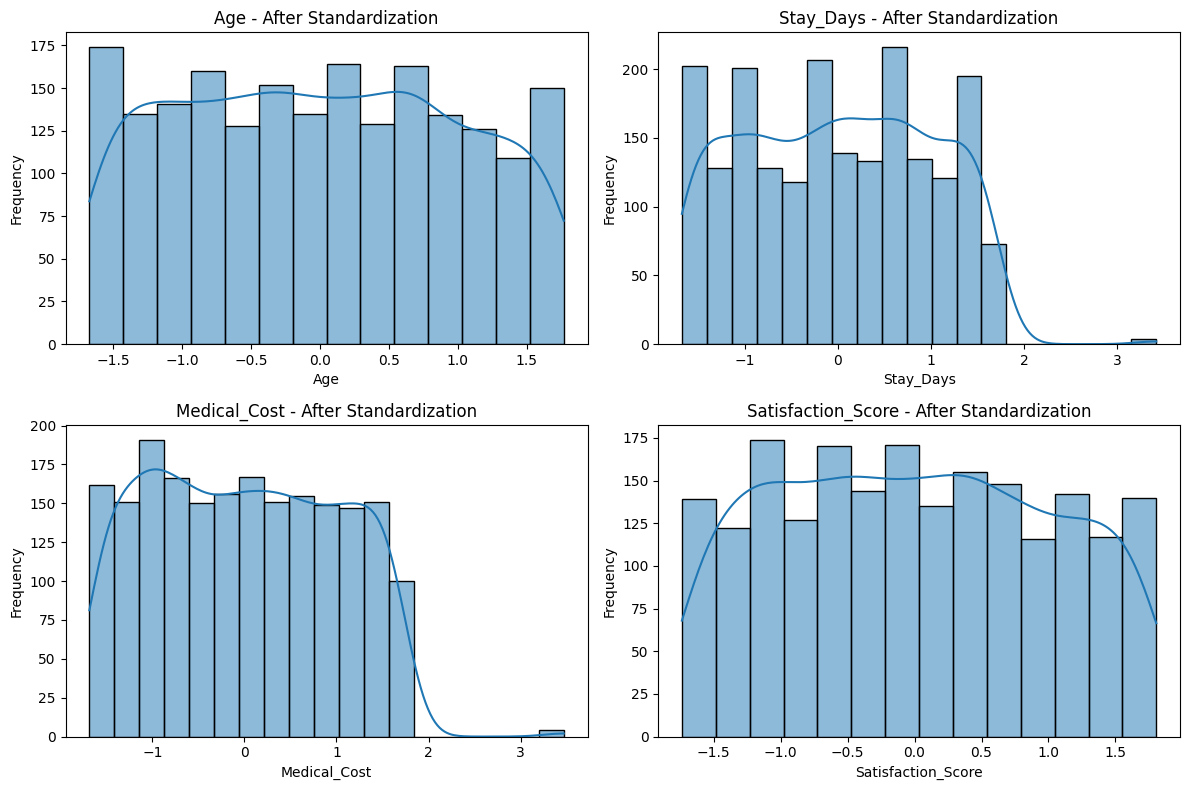

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features that were standardized for visualization
features_to_plot = ['Age', 'Stay_Days', 'Medical_Cost', 'Satisfaction_Score']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(features_to_plot):
    ax = axes[i // 2, i % 2]

    sns.histplot(df_encoded[col], kde=True, ax=ax)
    ax.set_title(f'{col} - After Standardization')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

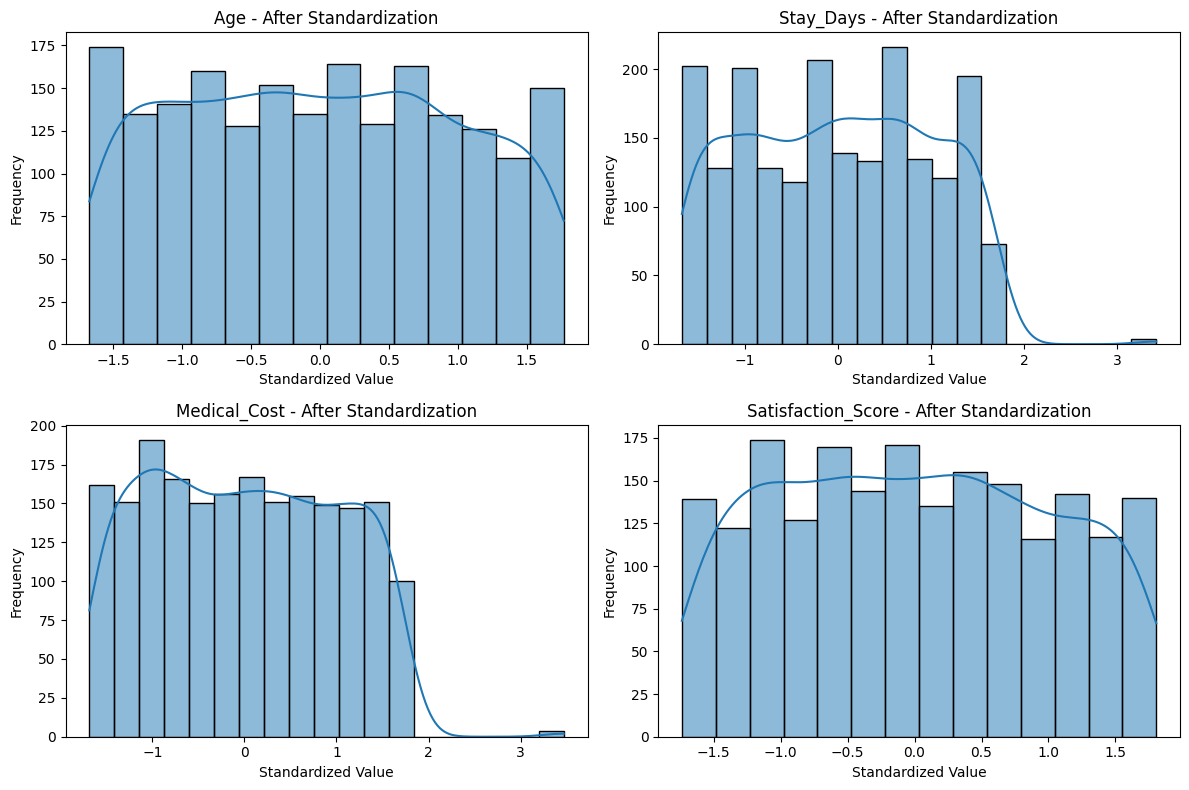

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(features_to_plot):
    ax = axes[i // 2, i % 2]

    sns.histplot(df_encoded[col], kde=True, ax=ax)
    ax.set_title(f'{col} - After Standardization')
    ax.set_xlabel('Standardized Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [55]:
# Create 5 meaningful features

# Correcting NameError: 'df_clean' is not defined. Using 'df_encoded'.
# Also correcting column name 'Date' to 'Admission_Date' as per current dataframe.
df_encoded['Day_of_Week'] = df_encoded['Admission_Date'].dt.dayofweek
df_encoded['Month'] = df_encoded['Admission_Date'].dt.month

# The following lines are commented out because columns like 'Unit price', 'Quantity',
# 'Gross income', 'Total', and 'Rating' do not exist in the current dataset ('healthcare_patient_dataset').
# If you intended to create similar features for this dataset, you would need to identify
# equivalent columns or define new relevant features based on available data.
# df_encoded['Sales_Revenue_Before_Tax'] = (
#     df_encoded['Unit price'] * df_encoded['Quantity']
# )

# df_encoded['Profit_Per_Unit'] = (
#     df_encoded['Gross income'] / df_encoded['Quantity']
# )

# df_encoded['Sales_Per_Rating_Point'] = (
#     df_encoded['Total'] / df_encoded['Rating']
# )

print("Meaningful features created successfully: Day_of_Week, Month!")

display(df_encoded[
    [
        'Day_of_Week',
        'Month'
        # 'Sales_Revenue_Before_Tax',
        # 'Profit_Per_Unit',
        # 'Sales_Per_Rating_Point'
    ]
].head())

print("\nDataset shape after feature engineering:", df_encoded.shape)

Meaningful features created successfully: Day_of_Week, Month!


,Day_of_Week,Month
0,1,8
1,0,7
2,0,1
3,0,12
4,5,6



Dataset shape after feature engineering: (2000, 48)


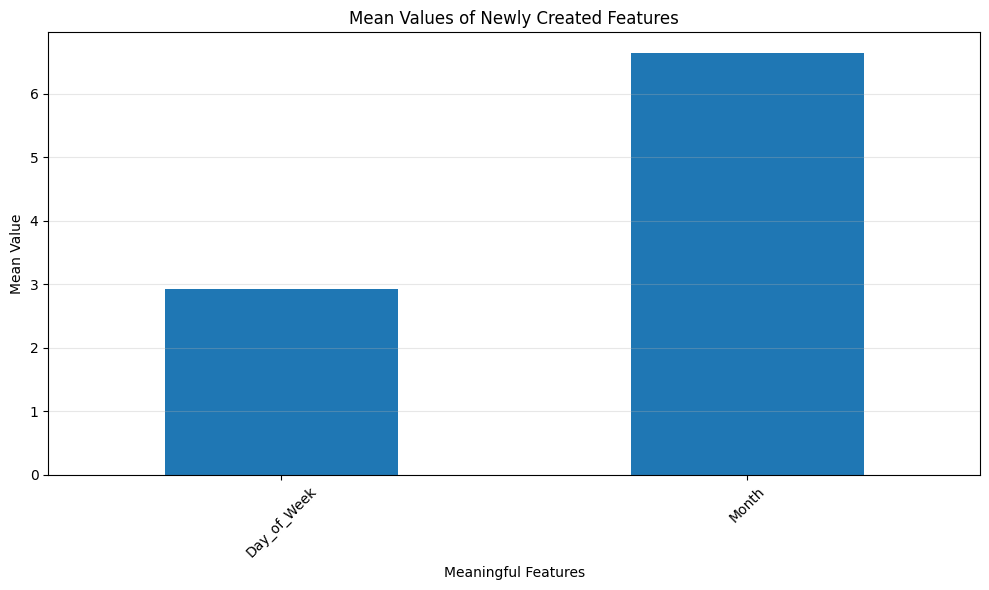

In [56]:
 #Graph of the meaningful features

import matplotlib.pyplot as plt

# Correcting NameError: 'df_clean' is not defined. Using 'df_encoded'.
# Also, only 'Day_of_Week' and 'Month' were successfully created.
feature_means = df_encoded[
    [
        'Day_of_Week',
        'Month'
    ]
].mean()

plt.figure(figsize=(10, 6))
feature_means.plot(kind='bar')

plt.title('Mean Values of Newly Created Features')
plt.xlabel('Meaningful Features')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
# Descriptive Statistics Before and After Preprocessing

# Original dataset (before preprocessing)
df_before_stats = pd.read_csv(dataset_path)

print("===== DESCRIPTIVE STATISTICS BEFORE PREPROCESSING =====")
display(df_before_stats.describe().T.round(2))

print("\n===== DESCRIPTIVE STATISTICS AFTER PREPROCESSING =====")
display(df_encoded.describe().T.round(2))

===== DESCRIPTIVE STATISTICS BEFORE PREPROCESSING =====


,count,mean,std,min,25%,50%,75%,max
Age,1988.0,43.79,25.64,1.00,22.00,44.00,64.0,89.0
Stay_Days,2000.0,15.81,10.29,1.00,8.00,16.00,23.0,180.0
Medical_Cost,1990.0,127111.46,76067.10,5294.89,62811.11,124583.16,188822.4,900000.0
Satisfaction_Score,1992.0,5.41,2.55,1.00,3.20,5.40,7.5,10.0



===== DESCRIPTIVE STATISTICS AFTER PREPROCESSING =====


,count,mean,min,25%,50%,75%,max,std
Age,2000.0,0.0,-1.67436,-0.852684,0.008119,0.790667,1.768852,1.00025
Admission_Date,2000,2024-12-31 06:54:43.200000,2024-01-01 00:00:00,2024-07-05 00:00:00,2024-12-24 00:00:00,2025-07-05 06:00:00,2025-12-31 00:00:00,NaN
Stay_Days,2000.0,-0.0,-1.675603,-0.873714,0.042729,0.844617,3.422115,1.00025
Medical_Cost,2000.0,-0.0,-1.68353,-0.880381,-0.025954,0.859193,3.468553,1.00025
Satisfaction_Score,2000.0,-0.0,-1.737433,-0.841971,-0.00555,0.821031,1.805055,1.00025
Day_of_Week,2000.0,2.9225,0.0,1.0,3.0,5.0,6.0,2.003123
Month,2000.0,6.6335,1.0,4.0,7.0,10.0,12.0,3.501615


In [58]:
# Explanation of Preprocessing Steps

preprocessing_explanation = {
    "1. Missing Values":
        "Missing values were identified and handled using mode for categorical data and median for numerical data. This prevents loss of records and maintains data consistency.",

    "2. Duplicate Records":
        "Duplicate records were identified and removed to prevent repeated transactions from affecting the analysis and statistical results.",

    "3. Outliers":
        "Outliers were detected using the IQR method and capped at the lower and upper bounds. This reduces the excessive influence of extreme values while retaining the observations.",

    "4. Data Types":
        "The Date column was converted from object/string format to datetime format so that date-based features could be extracted correctly.",

    "5. Categorical Encoding":
        "Categorical variables were converted into numerical form using one-hot encoding so that they can be processed by machine learning algorithms. Invoice ID was excluded because it is only an identifier.",

    "6. Standardization":
        "Numerical features were standardized using StandardScaler so that features with different scales can contribute more consistently to analysis and machine learning models.",

    "7. Feature Engineering":
        "Five meaningful features were created to extract additional business insights from the existing data: Day of Week, Month, Sales Revenue Before Tax, Profit Per Unit, and Sales Per Rating Point."
}

for step, explanation in preprocessing_explanation.items():
    print(f"\n{step}:")
    print(explanation)


1. Missing Values:
Missing values were identified and handled using mode for categorical data and median for numerical data. This prevents loss of records and maintains data consistency.

2. Duplicate Records:
Duplicate records were identified and removed to prevent repeated transactions from affecting the analysis and statistical results.

3. Outliers:
Outliers were detected using the IQR method and capped at the lower and upper bounds. This reduces the excessive influence of extreme values while retaining the observations.

4. Data Types:
The Date column was converted from object/string format to datetime format so that date-based features could be extracted correctly.

5. Categorical Encoding:
Categorical variables were converted into numerical form using one-hot encoding so that they can be processed by machine learning algorithms. Invoice ID was excluded because it is only an identifier.

6. Standardization:
Numerical features were standardized using StandardScaler so that featur

In [59]:
# BONUS: Automated Preprocessing Pipeline using Scikit-learn

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Reload original dataset
df_pipeline = pd.read_csv(dataset_path)

# Convert Admission_Date
df_pipeline['Admission_Date'] = pd.to_datetime(
    df_pipeline['Admission_Date'],
    errors='coerce'
)

# Remove duplicate records
df_pipeline = df_pipeline.drop_duplicates().reset_index(drop=True)

# Create meaningful features from Admission_Date
df_pipeline['Day_of_Week'] = df_pipeline['Admission_Date'].dt.dayofweek
df_pipeline['Month'] = df_pipeline['Admission_Date'].dt.month

# The following lines are commented out because their source columns
# ('Unit price', 'Quantity', 'Gross income', 'Total', 'Rating')
# do not exist in the current 'healthcare_patient_dataset'.
# df_pipeline['Sales_Revenue_Before_Tax'] = (
#     df_pipeline['Unit price'] * df_pipeline['Quantity']
# )
# df_pipeline['Profit_Per_Unit'] = (
#     df_pipeline['Gross income'] / df_pipeline['Quantity']
# )
# df_pipeline['Sales_Per_Rating_Point'] = (
#     df_pipeline['Total'] / df_pipeline['Rating']
# )

# Columns for preprocessing, adapted for healthcare_patient_dataset
numeric_features = [
    'Age',
    'Stay_Days',
    'Medical_Cost',
    'Satisfaction_Score',
    'Day_of_Week',
    'Month'
]

categorical_features = [
    'Gender',
    'Blood_Type',
    'City',
    'Department',
    'Diagnosis',
    'Treatment',
    'Medication',
    'Insurance',
    'Order_Status'
]

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Complete preprocessing pipeline
preprocessor = ColumnTransformer([
    ('numerical', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

# Apply pipeline
# Exclude 'Patient_ID' as it's an identifier and not a feature for modeling
features_to_process = numeric_features + categorical_features
X = df_pipeline[features_to_process]

X_processed = preprocessor.fit_transform(X)

print("===== AUTOMATED PREPROCESSING PIPELINE ====")
print("Pipeline created successfully!")
print("Original records:", len(df_pipeline))
print("Processed data shape:", X_processed.shape)
print("Numerical features used:", len(numeric_features))
print("Categorical features used:", len(categorical_features))

===== AUTOMATED PREPROCESSING PIPELINE ====
Pipeline created successfully!
Original records: 2000
Processed data shape: (2000, 46)
Numerical features used: 6
Categorical features used: 9


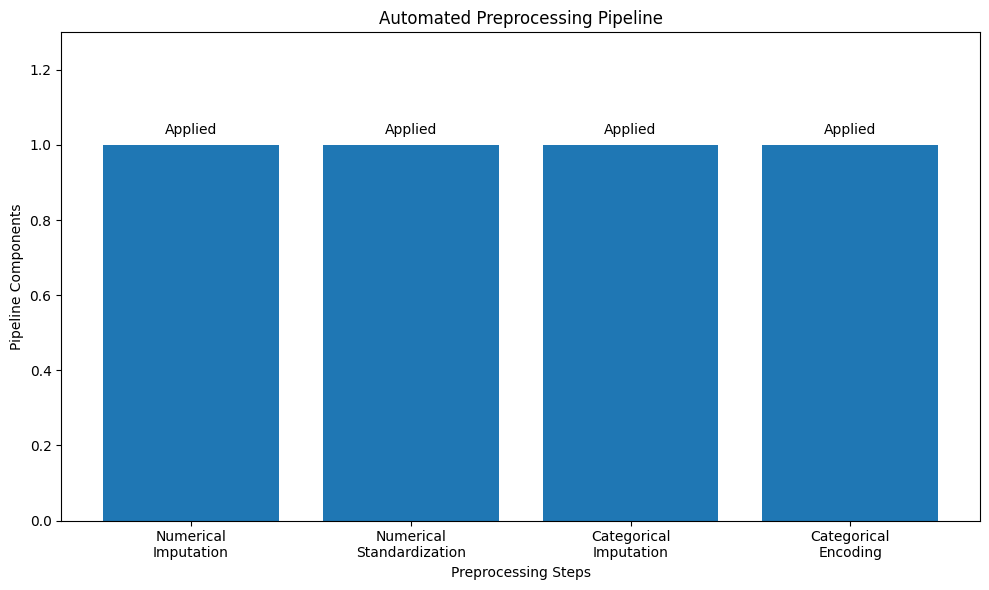

In [60]:
# Bonus: Automated Preprocessing Pipeline Visualization

import matplotlib.pyplot as plt

steps = [
    'Numerical\nImputation',
    'Numerical\nStandardization',
    'Categorical\nImputation',
    'Categorical\nEncoding'
]

values = [1, 1, 1, 1]

plt.figure(figsize=(10, 6))
plt.bar(steps, values)

plt.title('Automated Preprocessing Pipeline')
plt.xlabel('Preprocessing Steps')
plt.ylabel('Pipeline Components')
plt.ylim(0, 1.3)

for i, value in enumerate(values):
    plt.text(i, value + 0.03, 'Applied', ha='center')

plt.tight_layout()
plt.show()